<a href="https://colab.research.google.com/github/Amaru333/itis5122-project-1/blob/main/ITCS_5122_Project_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/NY_Airport.csv')

In [ ]:
df.head()

,Activity Period,Airport Code,Terminal Port,Marketing Airline Name,Direction,Market,World Region,Revenue Passenger Volume,Non-Revenue Passenger Volume,Freight Volume,Mail Volume,Total Flights
0,2000-01-01 00:00:00.0000000,EWR,General Aviation,General Aviation,Inbound,Domestic,DOMESTIC,0,0,0.0,0.0,641
1,2000-02-01 00:00:00.0000000,EWR,General Aviation,General Aviation,Inbound,Domestic,DOMESTIC,0,0,0.0,0.0,763
2,2000-03-01 00:00:00.0000000,EWR,General Aviation,General Aviation,Inbound,Domestic,DOMESTIC,0,0,0.0,0.0,777
3,2000-04-01 00:00:00.0000000,EWR,General Aviation,General Aviation,Inbound,Domestic,DOMESTIC,0,0,0.0,0.0,775
4,2000-05-01 00:00:00.0000000,EWR,General Aviation,General Aviation,Inbound,Domestic,DOMESTIC,0,0,0.0,0.0,841


In [ ]:
df.columns

Index(['Activity Period', 'Airport Code', 'Terminal Port',
       'Marketing Airline Name', 'Direction', 'Market', 'World Region',
       'Revenue Passenger Volume', 'Non-Revenue Passenger Volume',
       'Freight Volume', 'Mail Volume', 'Total Flights'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 691778 entries, 0 to 691777
Data columns (total 12 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Activity Period               691778 non-null  object 
 1   Airport Code                  691778 non-null  object 
 2   Terminal Port                 691778 non-null  object 
 3   Marketing Airline Name        691778 non-null  object 
 4   Direction                     691778 non-null  object 
 5   Market                        691778 non-null  object 
 6   World Region                  691778 non-null  object 
 7   Revenue Passenger Volume      691778 non-null  int64  
 8   Non-Revenue Passenger Volume  691778 non-null  int64  
 9   Freight Volume                691778 non-null  float64
 10  Mail Volume                   691778 non-null  float64
 11  Total Flights                 691778 non-null  int64  
dtypes: float64(2), int64(3), object(7)
memory us

In [ ]:
print(df.isnull().sum())

Activity Period                 0
Airport Code                    0
Terminal Port                   0
Marketing Airline Name          0
Direction                       0
Market                          0
World Region                    0
Revenue Passenger Volume        0
Non-Revenue Passenger Volume    0
Freight Volume                  0
Mail Volume                     0
Total Flights                   0
dtype: int64


In [ ]:
num_rows = df.shape[0]
print(f"The number of rows in the dataframe is: {num_rows}")

The number of rows in the dataframe is: 691778


In [ ]:
df.columns

Index(['Activity Period', 'Airport Code', 'Terminal Port',
       'Marketing Airline Name', 'Direction', 'Market', 'World Region',
       'Revenue Passenger Volume', 'Non-Revenue Passenger Volume',
       'Freight Volume', 'Mail Volume', 'Total Flights'],
      dtype='object')

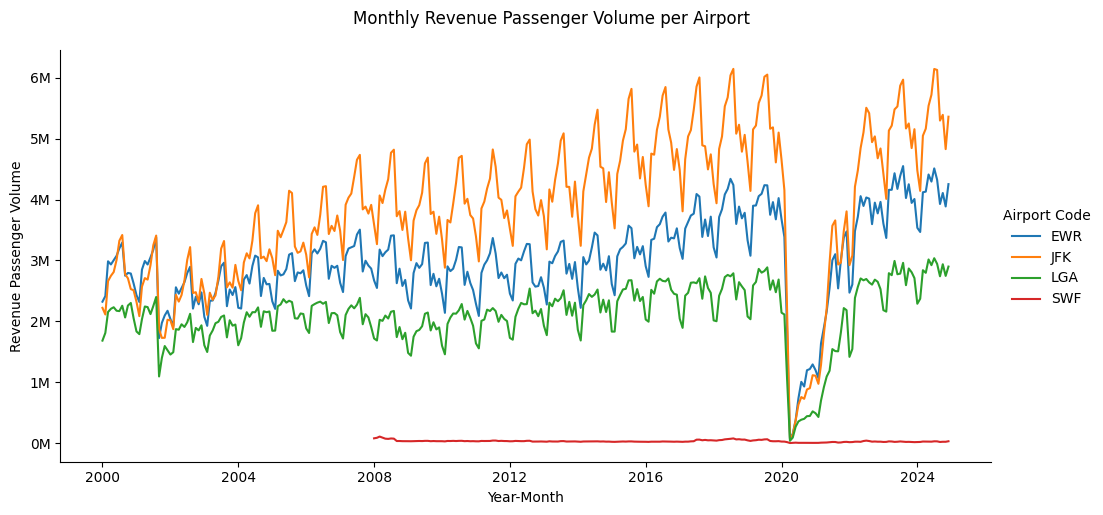

In [ ]:
df['Activity Period'] = pd.to_datetime(df['Activity Period'])
df['YearMonth'] = df['Activity Period'].dt.to_period('M')

filtered_df = df[(df['Activity Period'].dt.year >= 2000) & (df['Activity Period'].dt.year <= 2024)]

monthly_data = filtered_df.groupby(['YearMonth', 'Airport Code'])['Revenue Passenger Volume'].sum().reset_index()

monthly_data['YearMonth'] = monthly_data['YearMonth'].dt.to_timestamp()


plot = sns.relplot(
    kind="line",
    data=monthly_data,
    x="YearMonth",
    y="Revenue Passenger Volume",
    hue="Airport Code",
    height=5, aspect=2
)

plot.set_axis_labels("Year-Month", "Revenue Passenger Volume")

from matplotlib.ticker import FuncFormatter
def millions_formatter(x, pos):
    return f'{x/1e6:.0f}M'

plot.ax.yaxis.set_major_formatter(FuncFormatter(millions_formatter))
plot.fig.suptitle('Monthly Revenue Passenger Volume per Airport', y=1.02)

plt.show()

In [ ]:
df['Year'] = df['Activity Period'].dt.year

yearly_freight_data = df.groupby(['Year', 'Airport Code'])['Freight Volume'].sum().reset_index()

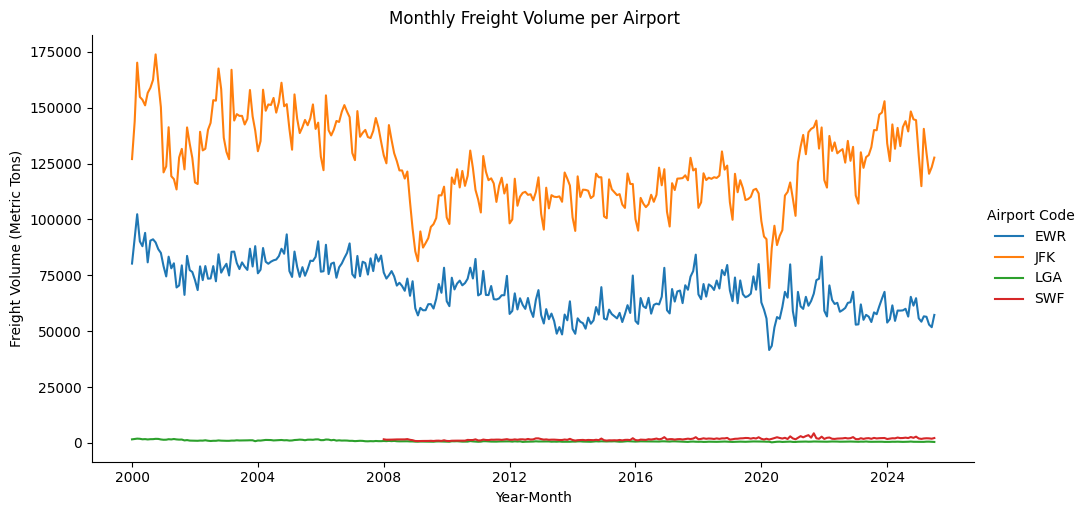

In [ ]:
df['Activity Period'] = pd.to_datetime(df['Activity Period'])
df['YearMonth'] = df['Activity Period'].dt.to_period('M')

monthly_freight_data = df.groupby(['YearMonth', 'Airport Code'])['Freight Volume'].sum().reset_index()

monthly_freight_data['YearMonth'] = monthly_freight_data['YearMonth'].dt.to_timestamp()


plot = sns.relplot(
    kind="line",
    data=monthly_freight_data,
    x="YearMonth",
    y="Freight Volume",
    hue="Airport Code",
    height=5, aspect=2
)

plot.set_axis_labels("Year-Month", "Freight Volume (Metric Tons)")
plot.fig.suptitle('Monthly Freight Volume per Airport', y=1.02)

plt.show()

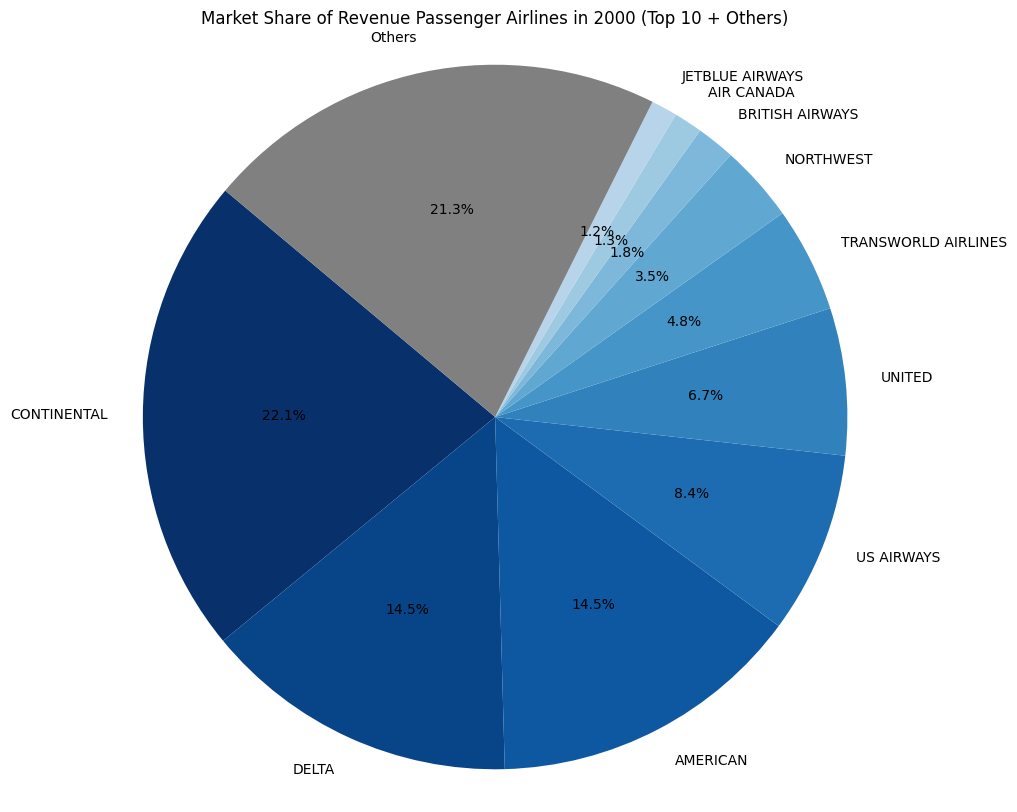

In [ ]:
import numpy as np
df_2000 = df[df['Activity Period'].dt.year == 2000]

airline_passenger_volume = df_2000.groupby('Marketing Airline Name')['Revenue Passenger Volume'].sum().reset_index()

top_10_airlines = airline_passenger_volume.nlargest(10, 'Revenue Passenger Volume')

others_volume = airline_passenger_volume[~airline_passenger_volume['Marketing Airline Name'].isin(top_10_airlines['Marketing Airline Name'])]['Revenue Passenger Volume'].sum()

others_row = pd.DataFrame({'Marketing Airline Name': ['Others'], 'Revenue Passenger Volume': [others_volume]})

pie_data = pd.concat([top_10_airlines, others_row])

plt.figure(figsize=(10, 10))
cmap = plt.get_cmap("Blues")
colors = list(cmap(np.linspace(1, 0.3, len(top_10_airlines))))
colors.append('gray')
plt.pie(pie_data['Revenue Passenger Volume'], labels=pie_data['Marketing Airline Name'], autopct='%1.1f%%', startangle=140, colors=colors)
plt.title('Market Share of Revenue Passenger Airlines in 2000 (Top 10 + Others)')
plt.axis('equal')

plt.show()

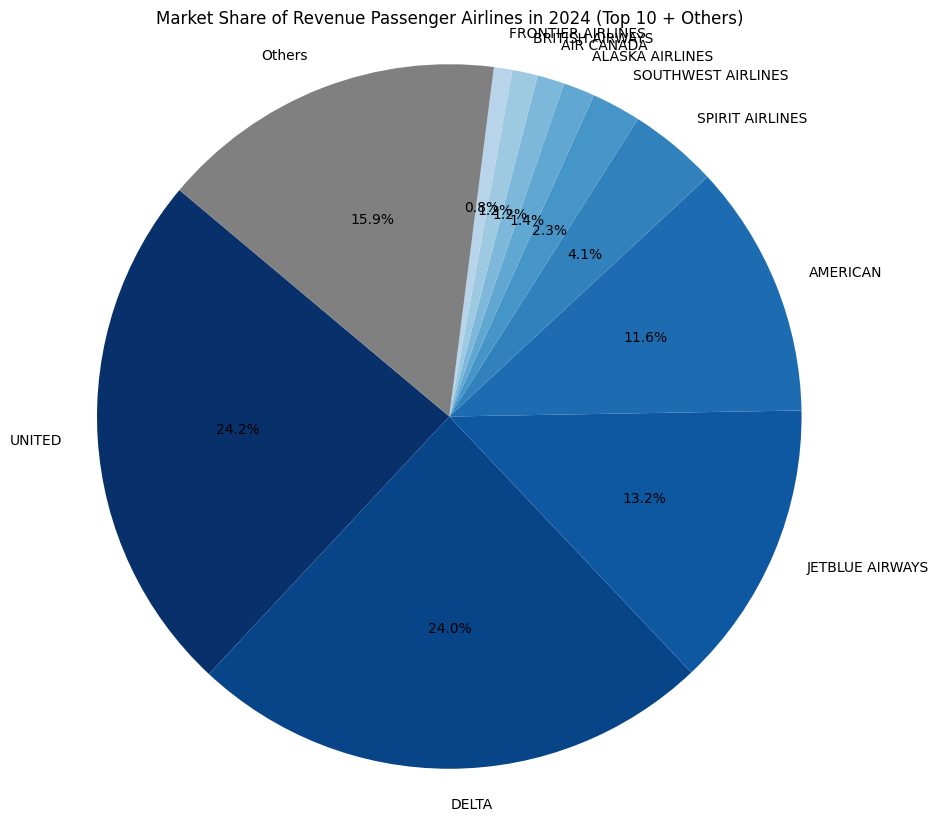

In [ ]:
import numpy as np
df_2024 = df[df['Activity Period'].dt.year == 2024]

airline_passenger_volume_2024 = df_2024.groupby('Marketing Airline Name')['Revenue Passenger Volume'].sum().reset_index()

top_10_airlines_2024 = airline_passenger_volume_2024.nlargest(10, 'Revenue Passenger Volume')

others_volume_2024 = airline_passenger_volume_2024[~airline_passenger_volume_2024['Marketing Airline Name'].isin(top_10_airlines_2024['Marketing Airline Name'])]['Revenue Passenger Volume'].sum()

others_row_2024 = pd.DataFrame({'Marketing Airline Name': ['Others'], 'Revenue Passenger Volume': [others_volume_2024]})

pie_data_2024 = pd.concat([top_10_airlines_2024, others_row_2024])

plt.figure(figsize=(10, 10))
cmap = plt.get_cmap("Blues")
colors = list(cmap(np.linspace(1, 0.3, len(top_10_airlines_2024))))
colors.append('gray')
plt.pie(pie_data_2024['Revenue Passenger Volume'], labels=pie_data_2024['Marketing Airline Name'], autopct='%1.1f%%', startangle=140, colors=colors)
plt.title('Market Share of Revenue Passenger Airlines in 2024 (Top 10 + Others)')
plt.axis('equal')

plt.show()